       A        B        C        D        E
0   1750  2.10760  7.87110  1.54160  5.86280
1   1755  2.11414  7.89598  1.54814  5.88768
2   1760  2.12068  7.92086  1.55468  5.91256
3   1765  2.12722  7.94574  1.56122  5.93744
4   1770  2.13376  7.97062  1.56776  5.96232
5   1775  2.14030  7.99550  1.57430  5.98720
6   1780  2.14662  8.01950  1.58062  6.01120
7   1785  2.15294  8.04350  1.58694  6.03520
8   1790  2.15926  8.06750  1.59326  6.05920
9   1795  2.16558  8.09150  1.59958  6.08320
10  1800  2.17190  8.11550  1.60590  6.10720
11  1805  2.17800  8.13868  1.61200  6.13038
12  1810  2.18410  8.16186  1.61810  6.15356
13  1815  2.19020  8.18504  1.62420  6.17674
14  1820  2.19630  8.20822  1.63030  6.19992
15  1825  2.20240  8.23140  1.63640  6.22310
16  1830  2.20854  8.25370  1.64254  6.24540
17  1835  2.21468  8.27600  1.64868  6.26770
18  1840  2.22082  8.29830  1.65482  6.29000
19  1845  2.22696  8.32060  1.66096  6.31230
20  1850  2.23310  8.34290  1.66710  6.33460
21  1855  

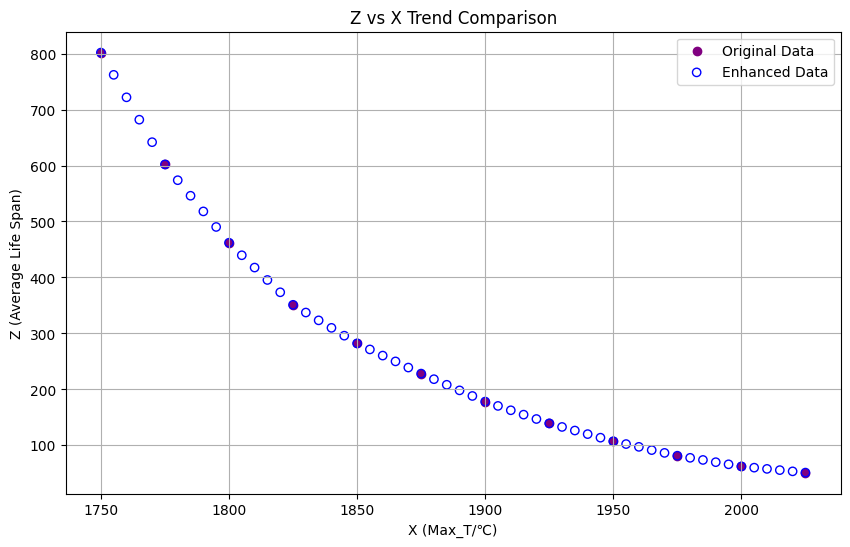

Enhanced Data Table:
X	Y1	Y2	Y3	Y4	Y5	Z
1750	618	694	872	896	930	802.0
1755	588	652	825	851	895	762.2
1760	557	610	778	806	859	722.0
1765	527	567	732	760	824	682.0
1770	496	525	685	715	788	641.8
1775	466	483	638	670	753	602.0
1780	444	459	596	651	719	573.8
1785	422	436	555	632	685	546.0
1790	399	412	513	614	652	518.0
1795	377	389	472	595	618	490.2
1800	355	365	430	576	584	462.0
1805	339	355	416	535	553	439.6
1810	324	346	402	494	522	417.6
1815	308	336	389	454	490	395.4
1820	293	327	375	413	459	373.4
1825	277	317	361	372	428	351.0
1830	264	304	346	359	413	337.2
1835	251	291	331	346	397	323.2
1840	238	279	317	333	382	309.8
1845	225	266	302	320	366	295.8
1850	212	253	287	307	351	282.0
1855	205	244	276	297	334	271.2
1860	199	234	264	287	317	260.2
1865	192	225	253	278	301	249.8
1870	186	215	241	268	284	238.8
1875	179	206	230	258	267	228.0
1880	170	198	219	246	257	218.0
1885	162	189	208	234	247	208.0
1890	153	181	198	221	237	198.0
1895	145	172	187	209	227	188.0
1900	136	164	176	197	217	178.0

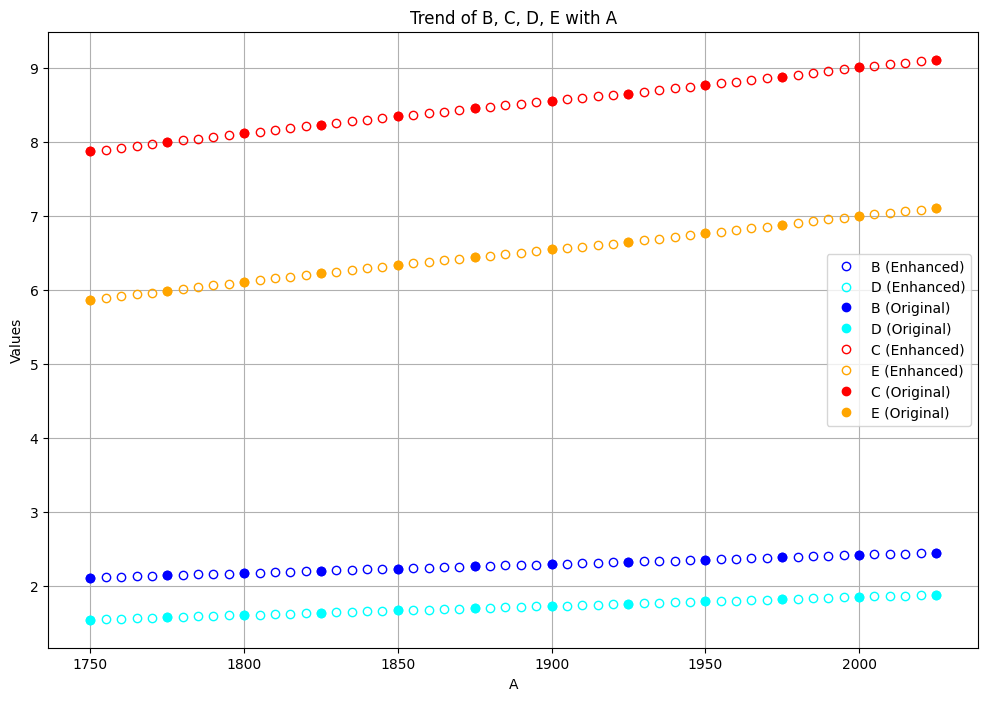

拟合得到的参数 a = 12.720027421233029, b = -13.864917940293203
拟合得到的参数 a = 32.3919826380731, b = -14.503743166664327


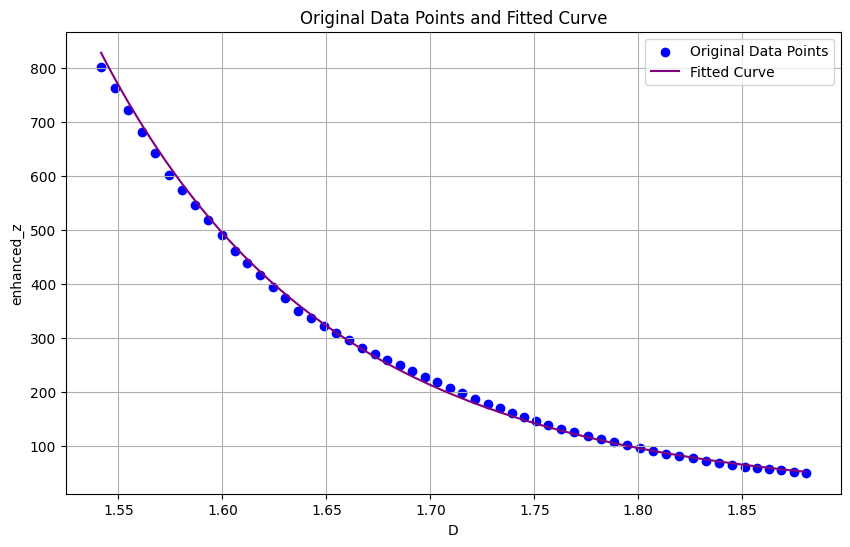

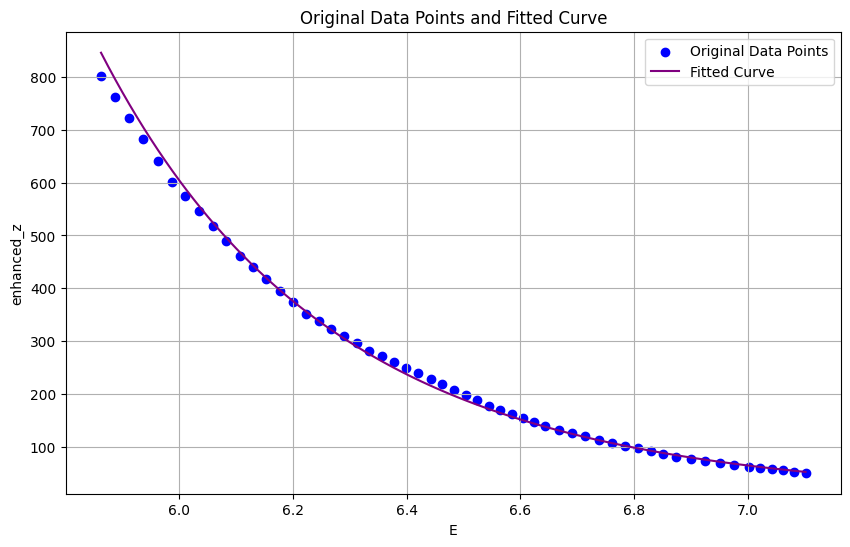

当 D = 1.5416 时，预测的 enhanced_z 值为: 827.9907790231331
当 D = 1.5743 时，预测的 enhanced_z 值为: 618.9217819158672
当 D = 5.8628 时，预测的 enhanced_z 值为: 845.7860624174834
当 D = 5.9872 时，预测的 enhanced_z 值为: 623.7426414950705


In [3]:
import bisect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 原始数据
original_data = {
    1750: [618, 694, 872, 896, 930],
    1775: [466, 483, 638, 670, 753],
    1800: [355, 365, 430, 576, 584],
    1825: [277, 317, 361, 372, 428],
    1850: [212, 253, 287, 307, 351],
    1875: [179, 206, 230, 258, 267],
    1900: [136, 164, 176, 197, 217],
    1925: [111, 126, 135, 148, 175],
    1950: [79, 86, 109, 129, 132],
    1975: [53, 60, 83, 98, 112],
    2000: [42, 57, 61, 67, 83],
    2025: [35, 43, 50, 59, 68]
}

# 生成增强后的X范围（1800-2025，间隔5℃）
x_target = list(range(1750, 2026, 5))
sorted_original_x = sorted(original_data.keys())
enhanced = []

# 处理每个目标X值
for x in x_target:
    if x in original_data:
        y_values = original_data[x]
    else:
        # 查找相邻的原始数据点
        pos = bisect.bisect_left(sorted_original_x, x)
        x_prev = sorted_original_x[pos-1]
        x_next = sorted_original_x[pos]
        ratio = (x - x_prev) / (x_next - x_prev)
        
        # 线性插值每个Y分量
        y_values = []
        for i in range(5):
            delta = original_data[x_next][i] - original_data[x_prev][i]
            interpolated = original_data[x_prev][i] + delta * ratio
            y_values.append(round(interpolated))
    
    # 计算Z值
    z = sum(y_values) / len(y_values)
    enhanced.append([x] + y_values + [z])

# 生成原始数据的Z值
original_z = {x: sum(ys)/len(ys) for x, ys in original_data.items()}


data = {
    'A': [1750, 1775, 1800, 1825, 1850, 1875, 1900, 1925, 1950, 1975, 2000, 2025],
    'B': [2.1076, 2.1403, 2.1719, 2.2024, 2.2331, 2.2633, 2.2935, 2.3224, 2.3543, 2.3857, 2.4174, 2.4464],
    'C': [7.8711, 7.9955, 8.1155, 8.2314, 8.3429, 8.4503, 8.5533, 8.6521, 8.7696, 8.8822, 9.0099, 9.1094]
}

# 转换为DataFrame
df = pd.DataFrame(data)

# 数据增强
new_A = np.arange(1750, 2025 + 5, 5)
new_B = np.interp(new_A, df['A'], df['B'])
new_C = np.interp(new_A, df['A'], df['C'])

# 计算D和E
new_D = new_B - 0.5660
new_E = new_C - 2.0083

# 生成增强后的DataFrame
enhanced_df = pd.DataFrame({
    'A': new_A,
    'B': new_B,
    'C': new_C,
    'D': new_D,
    'E': new_E
})

print(enhanced_df)


# 绘制趋势图
plt.figure(figsize=(10, 6))
# 原始数据点
plt.scatter(
    original_z.keys(), original_z.values(),
    color='purple', marker='o', label='Original Data'
)
# 增强数据点
enhanced_x = [row[0] for row in enhanced]
enhanced_z = [row[-1] for row in enhanced]
plt.scatter(
    enhanced_x, enhanced_z,
    facecolors='none', edgecolors='blue',
    marker='o', label='Enhanced Data'
)

plt.title('Z vs X Trend Comparison')
plt.xlabel('X (Max_T/℃)')
plt.ylabel('Z (Average Life Span)')
plt.grid(True)
plt.legend()
plt.show()

# 输出增强后的表格
print("Enhanced Data Table:")
print("X\tY1\tY2\tY3\tY4\tY5\tZ")
for row in enhanced:
    print(f"{row[0]}\t{row[1]}\t{row[2]}\t{row[3]}\t{row[4]}\t{row[5]}\t{row[6]:.1f}")

# 绘制变化趋势图
plt.figure(figsize=(12, 8))

# 绘制B和D
plt.plot(enhanced_df['A'], enhanced_df['B'], 'o', fillstyle='none', color='blue', label='B (Enhanced)')
plt.plot(enhanced_df['A'], enhanced_df['D'], 'o', fillstyle='none', color='cyan', label='D (Enhanced)')
plt.plot(df['A'], df['B'], 'o', color='blue', label='B (Original)')
plt.plot(df['A'], df['B'] - 0.5660, 'o', color='cyan', label='D (Original)')

# 绘制C和E
plt.plot(enhanced_df['A'], enhanced_df['C'], 'o', fillstyle='none', color='red', label='C (Enhanced)')
plt.plot(enhanced_df['A'], enhanced_df['E'], 'o', fillstyle='none', color='orange', label='E (Enhanced)')
plt.plot(df['A'], df['C'], 'o', color='red', label='C (Original)')
plt.plot(df['A'], df['C'] - 2.0083, 'o', color='orange', label='E (Original)')

plt.xlabel('A')
plt.ylabel('Values')
plt.title('Trend of B, C, D, E with A')
plt.legend()
plt.grid(True)
plt.show()

ln_D = np.log(enhanced_df['D'])
ln_E = np.log(enhanced_df['E'])
ln_enhanced_z = np.log(enhanced_z)

# 线性最小二乘拟合
A = np.vstack([ln_D, np.ones(len(ln_D))]).T
b, a = np.linalg.lstsq(A, ln_enhanced_z, rcond=None)[0]
A_2 = np.vstack([ln_E, np.ones(len(ln_E))]).T
b1, a1 = np.linalg.lstsq(A_2, ln_enhanced_z, rcond=None)[0]


print(f"拟合得到的参数 a = {a}, b = {b}")
print(f"拟合得到的参数 a = {a1}, b = {b1}")
# 绘制原数据点和拟合曲线
plt.figure(figsize=(10, 6))

# 绘制原数据点
plt.scatter(enhanced_df['D'], enhanced_z, color='blue', label='Original Data Points')

# 生成用于绘制拟合曲线的 D 值
D_fit = np.linspace(min(enhanced_df['D']), max(enhanced_df['D']), 100)
# 根据拟合参数计算对应的 enhanced_z 值
enhanced_z_fit = np.exp(a + b * np.log(D_fit))

# 绘制拟合曲线
plt.plot(D_fit, enhanced_z_fit, color='purple', label='Fitted Curve')

plt.xlabel('D')
plt.ylabel('enhanced_z')
plt.title('Original Data Points and Fitted Curve')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))

# 绘制原数据点
plt.scatter(enhanced_df['E'], enhanced_z, color='blue', label='Original Data Points')

# 生成用于绘制拟合曲线的 D 值
E_fit = np.linspace(min(enhanced_df['E']), max(enhanced_df['E']), 100)
# 根据拟合参数计算对应的 enhanced_z 值
enhanced_z_fit = np.exp(a1 + b1 * np.log(E_fit))

# 绘制拟合曲线
plt.plot(E_fit, enhanced_z_fit, color='purple', label='Fitted Curve')

plt.xlabel('E')
plt.ylabel('enhanced_z')
plt.title('Original Data Points and Fitted Curve')
plt.legend()
plt.grid(True)
plt.show()
# 计算当 D 为 1.5416 和 1.5743 时预测的 enhanced_z 值
target_D = [1.5416, 1.5743]
predicted_enhanced_z = []
for d in target_D:
    pred_enhanced_z = np.exp(a + b * np.log(d))
    predicted_enhanced_z.append(pred_enhanced_z)
    print(f"当 D = {d} 时，预测的 enhanced_z 值为: {pred_enhanced_z}")

target_E = [5.8628, 5.9872]
predicted_enhanced_z1 = []
for e in target_E:
    pred_enhanced_z1 = np.exp(a1 + b1 * np.log(e))
    predicted_enhanced_z1.append(pred_enhanced_z1)
    print(f"当 D = {e} 时，预测的 enhanced_z 值为: {pred_enhanced_z1}")



Skipping invalid segment 3: [109, 109]


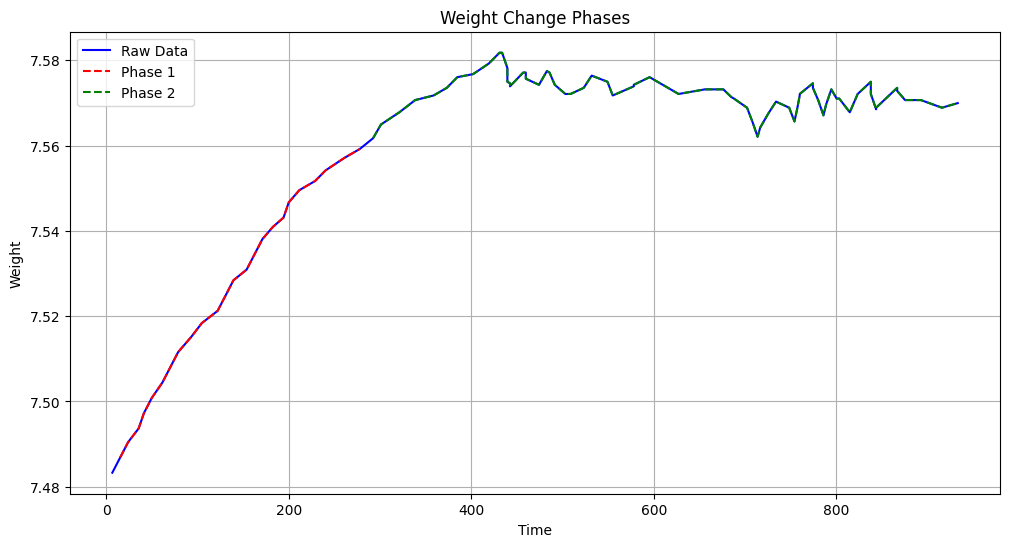

Phase Analysis Report:

Phase 1:
Time Range: 6.5 - 277.91
Best Fit: quadratic Model
Equation:             2
-4.097e-07 x + 0.0004002 x + 7.481
Goodness of Fit (R²): 0.9977

Phase 2:
Time Range: 292.34 - 933.33
Best Fit: quadratic Model
Equation:             2
-3.192e-08 x + 3.03e-05 x + 7.567
Goodness of Fit (R²): 0.2055


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score
import ruptures as rpt

# 读取数据并清洗
df = pd.read_excel("数据.xlsx", header=None)
time = df.iloc[10, 2:].values.astype(float)
weight = df.iloc[11, 2:].values.astype(float)

# 清除无效数据点（NaN/Inf）
valid_mask = ~np.isnan(time) & ~np.isnan(weight) & ~np.isinf(time) & ~np.isinf(weight)
time = time[valid_mask]
weight = weight[valid_mask]

# 变点检测（基于清洗后的数据）
algo = rpt.Pelt(model="rbf").fit(weight.reshape(-1, 1))
change_points = algo.predict(pen=10)
segments = [0] + change_points + [len(weight)]  # 确保包含数据末尾

results = []

# 遍历所有分段
for i in range(len(segments)-1):
    start_idx = segments[i]
    end_idx = segments[i+1]
    
    # 跳过无效分段
    if start_idx >= end_idx:
        print(f"Skipping invalid segment {i+1}: [{start_idx}, {end_idx}]")
        continue
    
    t_segment = time[start_idx:end_idx]
    w_segment = weight[start_idx:end_idx]
    
    # 检查分段长度
    if len(t_segment) < 2:
        print(f"Segment {i+1} has insufficient data (at least 2 points needed)")
        continue
    
    models = {}
    # 尝试线性拟合
    try:
        models['linear'] = np.poly1d(np.polyfit(t_segment, w_segment, 1))
    except Exception as e:
        print(f"Linear fitting failed for phase {i+1}: {e}")
    
    # 仅当数据足够时尝试二次拟合
    if len(t_segment) >= 3:
        try:
            models['quadratic'] = np.poly1d(np.polyfit(t_segment, w_segment, 2))
        except Exception as e:
            print(f"Quadratic fitting failed for phase {i+1}: {e}")
    
    if not models:
        print(f"No valid fitting models for phase {i+1}")
        continue
    
    # 选择最佳模型
    best_model = None
    best_r2 = -np.inf
    best_type = None
    for name, model in models.items():
        r2 = r2_score(w_segment, model(t_segment))
        if r2 > best_r2:
            best_r2, best_model, best_type = r2, model, name
    
    results.append({
        "Phase": i+1,
        "Time Range": (round(t_segment[0], 2), round(t_segment[-1], 2)),
        "Model Type": best_type,
        "Equation": best_model,
        "R²": round(best_r2, 4)
    })

# 可视化阶段划分
plt.figure(figsize=(12, 6))
plt.plot(time, weight, 'b-', label='Raw Data')

colors = ['r', 'g', 'm', 'c']
for idx, res in enumerate(results):
    t_start, t_end = res["Time Range"]
    mask = (time >= t_start) & (time <= t_end)
    plt.plot(time[mask], weight[mask], 
             colors[idx%4]+'--', 
             label=f'Phase {idx+1}')

plt.xlabel('Time')
plt.ylabel('Weight')
plt.title('Weight Change Phases')
plt.legend()
plt.grid(True)
plt.show()

# 输出分析结果
print("="*40 + "\nPhase Analysis Report:\n" + "="*40)
for res in results:
    print(f'\nPhase {res["Phase"]}:')
    print(f'Time Range: {res["Time Range"][0]} - {res["Time Range"][1]}')
    print(f'Best Fit: {res["Model Type"]} Model')
    print(f'Equation: {res["Equation"]}')
    print(f'Goodness of Fit (R²): {res["R²"]}')



/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAP

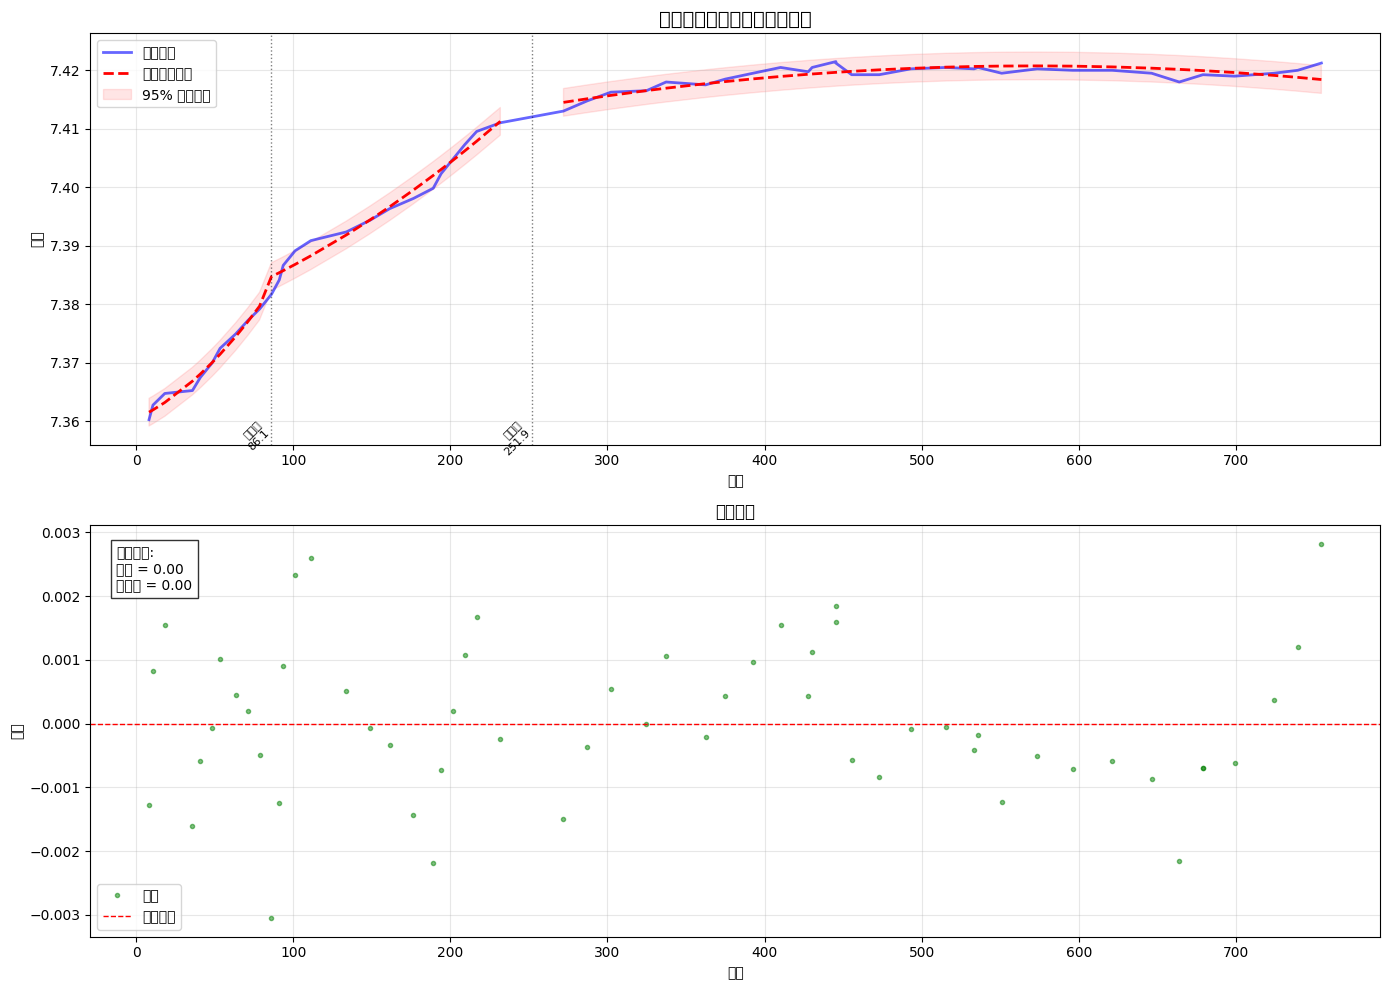


模型诊断报告:
全局残差标准差 (σ): 0.0012
平均绝对误差 (MAE): 0.0009
最大正残差: 0.0028
最大负残差: -0.0030

阶段 1:
├─ 局部残差标准差: 0.0010
└─ 残差范围: [-0.0016, 0.0015]

阶段 2:
├─ 局部残差标准差: 0.0015
└─ 残差范围: [-0.0030, 0.0026]

阶段 3:
├─ 局部残差标准差: 0.0011
└─ 残差范围: [-0.0022, 0.0028]


In [14]:
# 生成预测曲线数据（包含置信区间计算）
full_prediction = np.zeros_like(time) * np.nan
all_residuals = []
all_std = []

for res in results:
    t_start, t_end = res["时间范围"]
    mask = (time >= t_start) & (time <= t_end)
    t_segment = time[mask]
    w_segment = weight[mask]
    
    if len(t_segment) == 0:
        continue
    
    # 计算预测值
    prediction = res["方程"](t_segment)
    full_prediction[mask] = prediction
    
    # 计算残差和标准差
    residuals = w_segment - prediction
    all_residuals.extend(residuals)
    res["residuals"] = residuals
    res["std"] = np.std(residuals)
    all_std.append(res["std"])

# 计算全局标准差（加权平均）
global_std = np.mean(all_std)

# ====================== 可视化部分 ======================
# 1. 主对比图（含置信区间）
plt.figure(figsize=(14, 10))

# 原始数据与拟合曲线
ax1 = plt.subplot(2, 1, 1)
plt.plot(time, weight, 'b-', label='原始数据', alpha=0.6, linewidth=2)
pred_line, = plt.plot(time, full_prediction, 'r--', label='分段拟合曲线', linewidth=2)

# 置信区间（±2σ）
plt.fill_between(time,
                 full_prediction - 2*global_std,
                 full_prediction + 2*global_std,
                 color='r', alpha=0.1, label='95% 置信区间')

# 标注分段点
change_points_ts = [time[cp] for cp in change_points if cp < len(time)]
for cp in change_points_ts:
    plt.axvline(cp, color='k', linestyle=':', linewidth=1, alpha=0.5)
    plt.text(cp, np.min(weight), f'分段点\n{cp:.1f}', 
             rotation=45, ha='right', va='top', fontsize=8)

plt.title('重量变化数据与分段拟合对比', fontsize=14)
plt.xlabel('时间')
plt.ylabel('重量')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 2. 残差分析图
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
residuals = weight - full_prediction
plt.plot(time, residuals, 'g.', alpha=0.5, label='残差')
plt.axhline(0, color='r', linestyle='--', linewidth=1, label='零基准线')

# 添加残差分布统计
plt.text(0.02, 0.95, 
         f'残差统计:\n均值 = {np.nanmean(residuals):.2f}\n标准差 = {global_std:.2f}',
         transform=ax2.transAxes, va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8))

plt.title('残差分析')
plt.xlabel('时间')
plt.ylabel('残差')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 显示所有图形
plt.show()

# ====================== 输出统计报告 ======================
print("\n" + "="*40 + "\n模型诊断报告:\n" + "="*40)
print(f"全局残差标准差 (σ): {global_std:.4f}")
print(f"平均绝对误差 (MAE): {np.nanmean(np.abs(residuals)):.4f}")
print(f"最大正残差: {np.nanmax(residuals):.4f}")
print(f"最大负残差: {np.nanmin(residuals):.4f}")

for res in results:
    print(f'\n阶段 {res["阶段"]}:')
    print(f'├─ 局部残差标准差: {res["std"]:.4f}')
    print(f'└─ 残差范围: [{np.min(res["residuals"]):.4f}, {np.max(res["residuals"]):.4f}]')

跳过无效分段 4: [66, 66]


/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


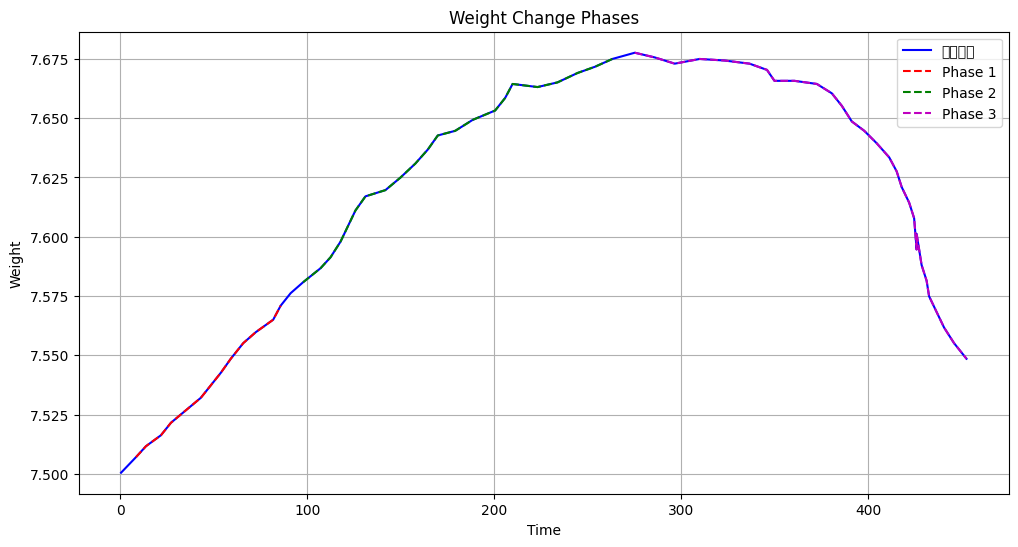

阶段分析报告：

阶段 1:
时间范围: 0.33 - 91.03
最佳拟合: quadratic方程
方程表达式:           2
1.12e-06 x + 0.0007243 x + 7.501
拟合度(R²): 0.9978

阶段 2:
时间范围: 97.7 - 263.1
最佳拟合: quadratic方程
方程表达式:             2
-2.915e-06 x + 0.00161 x + 7.451
拟合度(R²): 0.993

阶段 3:
时间范围: 275.1 - 452.51
最佳拟合: quadratic方程
方程表达式:             2
-8.085e-06 x + 0.00523 x + 6.837
拟合度(R²): 0.9618


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score
import ruptures as rpt

# 读取数据并清洗
df = pd.read_excel("数据.xlsx", header=None)
time = df.iloc[16, 2:].values.astype(float)
weight = df.iloc[17, 2:].values.astype(float)

# 清除无效数据点（NaN/Inf）
valid_mask = ~np.isnan(time) & ~np.isnan(weight) & ~np.isinf(time) & ~np.isinf(weight)
time = time[valid_mask]
weight = weight[valid_mask]

# 变点检测（基于清洗后的数据）
algo = rpt.Pelt(model="rbf").fit(weight.reshape(-1, 1))
change_points = algo.predict(pen=10)

# 添加最大值点作为必要切割点
max_idx = np.argmax(weight)  # 获取最大值点的索引
change_points = list(change_points)  # 转换为列表
change_points.append(max_idx)  # 添加最大值点
change_points = sorted(list(set(change_points)))  # 去重并排序

segments = [0] + change_points + [len(weight)]  # 确保包含数据末尾
results = []

# 遍历所有分段
for i in range(len(segments)-1):
    start_idx = segments[i]
    end_idx = segments[i+1]
    
    # 跳过无效分段
    if start_idx >= end_idx:
        print(f"跳过无效分段 {i+1}: [{start_idx}, {end_idx}]")
        continue
    
    t_segment = time[start_idx:end_idx]
    w_segment = weight[start_idx:end_idx]
    
    # 检查分段长度
    if len(t_segment) < 2:
        print(f"分段 {i+1} 数据不足，至少需要2个点")
        continue
    
    models = {}
    # 尝试线性拟合
    try:
        models['linear'] = np.poly1d(np.polyfit(t_segment, w_segment, 1))
    except Exception as e:
        print(f"阶段 {i+1} 线性拟合失败: {e}")
    
    # 仅当数据足够时尝试二次拟合
    if len(t_segment) >= 3:
        try:
            models['quadratic'] = np.poly1d(np.polyfit(t_segment, w_segment, 2))
        except Exception as e:
            print(f"阶段 {i+1} 二次拟合失败: {e}")
    
    if not models:
        print(f"阶段 {i+1} 无可用的拟合模型")
        continue
    
    # 选择最佳模型
    best_model = None
    best_r2 = -np.inf
    best_type = None
    for name, model in models.items():
        r2 = r2_score(w_segment, model(t_segment))
        if r2 > best_r2:
            best_r2, best_model, best_type = r2, model, name
    
    results.append({
        "阶段": i+1,
        "时间范围": (round(t_segment[0], 2), round(t_segment[-1], 2)),
        "方程类型": best_type,
        "方程": best_model,
        "R²": round(best_r2, 4)
    })

# 可视化阶段划分
plt.figure(figsize=(12, 6))
plt.plot(time, weight, 'b-', label='原始数据')

colors = ['r', 'g', 'm', 'c']
for idx, res in enumerate(results):
    t_start, t_end = res["时间范围"]
    mask = (time >= t_start) & (time <= t_end)
    plt.plot(time[mask], weight[mask], 
             colors[idx%4]+'--', 
             label=f'Phase {idx+1}')

plt.xlabel('Time')
plt.ylabel('Weight')
plt.title('Weight Change Phases')
plt.legend()
plt.grid(True)
plt.show()

# 输出分析结果
print("="*40 + "\n阶段分析报告：\n" + "="*40)
for res in results:
    print(f'\n阶段 {res["阶段"]}:')
    print(f'时间范围: {res["时间范围"][0]} - {res["时间范围"][1]}')
    print(f'最佳拟合: {res["方程类型"]}方程')
    print(f'方程表达式: {res["方程"]}')
    print(f'拟合度(R²): {res["R²"]}')


/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19512/3017623660.py:74: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAP

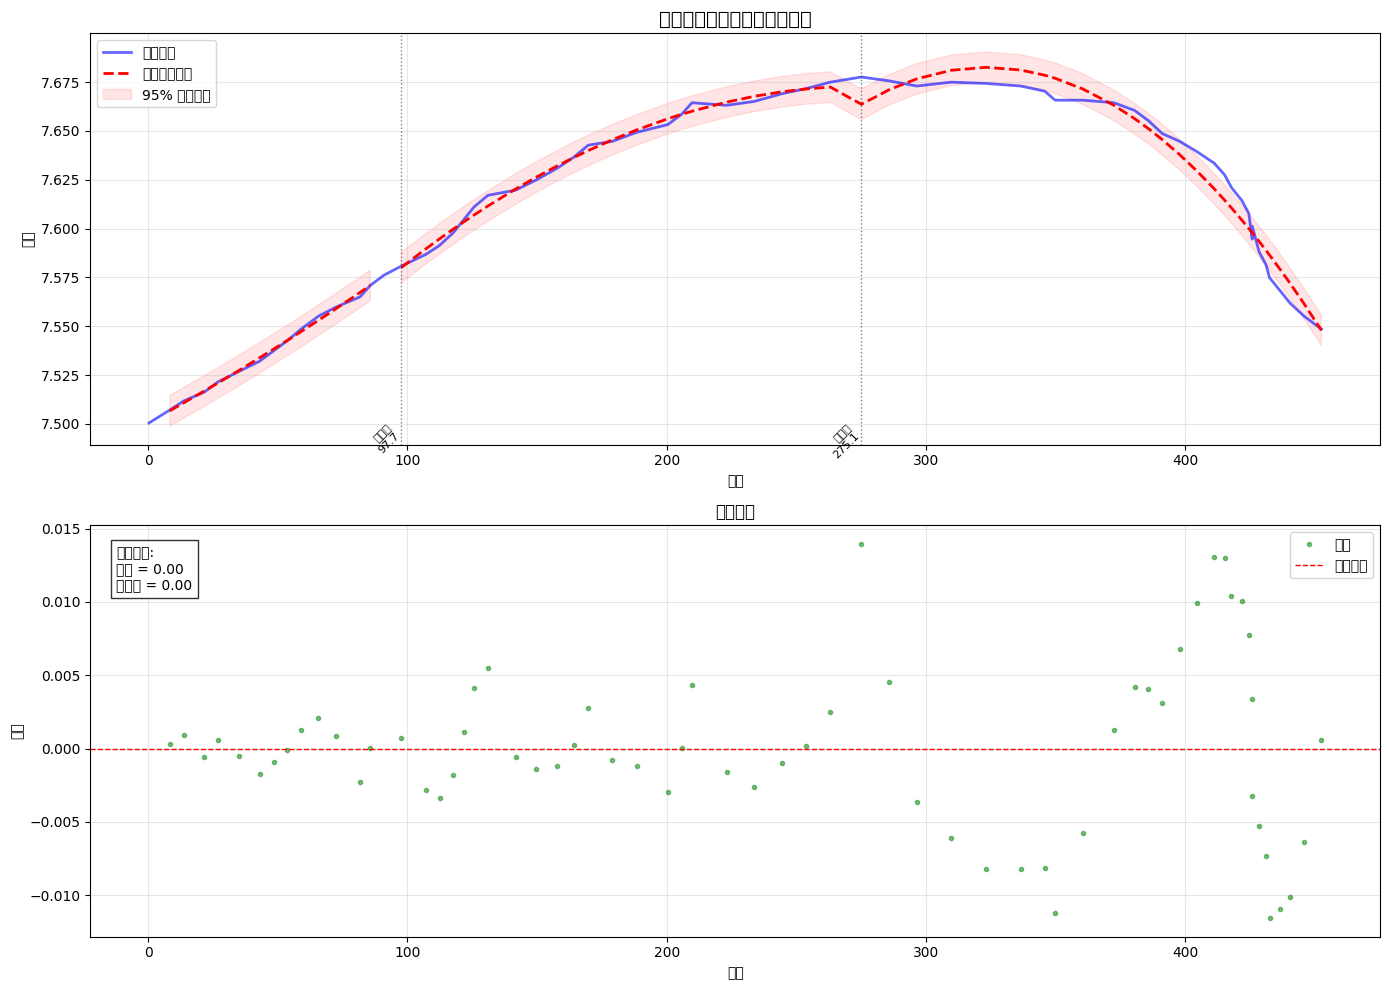


模型诊断报告:
全局残差标准差 (σ): 0.0039
平均绝对误差 (MAE): 0.0042
最大正残差: 0.0140
最大负残差: -0.0116

阶段 1:
├─ 局部残差标准差: 0.0012
└─ 残差范围: [-0.0023, 0.0021]

阶段 2:
├─ 局部残差标准差: 0.0024
└─ 残差范围: [-0.0034, 0.0055]

阶段 3:
├─ 局部残差标准差: 0.0081
└─ 残差范围: [-0.0116, 0.0140]


In [31]:
# 生成预测曲线数据（包含置信区间计算）
full_prediction = np.zeros_like(time) * np.nan
all_residuals = []
all_std = []

for res in results:
    t_start, t_end = res["时间范围"]
    mask = (time >= t_start) & (time <= t_end)
    t_segment = time[mask]
    w_segment = weight[mask]
    
    if len(t_segment) == 0:
        continue
    
    # 计算预测值
    prediction = res["方程"](t_segment)
    full_prediction[mask] = prediction
    
    # 计算残差和标准差
    residuals = w_segment - prediction
    all_residuals.extend(residuals)
    res["residuals"] = residuals
    res["std"] = np.std(residuals)
    all_std.append(res["std"])

# 计算全局标准差（加权平均）
global_std = np.mean(all_std)

# ====================== 可视化部分 ======================
# 1. 主对比图（含置信区间）
plt.figure(figsize=(14, 10))

# 原始数据与拟合曲线
ax1 = plt.subplot(2, 1, 1)
plt.plot(time, weight, 'b-', label='原始数据', alpha=0.6, linewidth=2)
pred_line, = plt.plot(time, full_prediction, 'r--', label='分段拟合曲线', linewidth=2)

# 置信区间（±2σ）
plt.fill_between(time,
                 full_prediction - 2*global_std,
                 full_prediction + 2*global_std,
                 color='r', alpha=0.1, label='95% 置信区间')

# 标注分段点
change_points_ts = [time[cp] for cp in change_points if cp < len(time)]
for cp in change_points_ts:
    plt.axvline(cp, color='k', linestyle=':', linewidth=1, alpha=0.5)
    plt.text(cp, np.min(weight), f'分段点\n{cp:.1f}', 
             rotation=45, ha='right', va='top', fontsize=8)

plt.title('重量变化数据与分段拟合对比', fontsize=14)
plt.xlabel('时间')
plt.ylabel('重量')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 2. 残差分析图
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
residuals = weight - full_prediction
plt.plot(time, residuals, 'g.', alpha=0.5, label='残差')
plt.axhline(0, color='r', linestyle='--', linewidth=1, label='零基准线')

# 添加残差分布统计
plt.text(0.02, 0.95, 
         f'残差统计:\n均值 = {np.nanmean(residuals):.2f}\n标准差 = {global_std:.2f}',
         transform=ax2.transAxes, va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8))

plt.title('残差分析')
plt.xlabel('时间')
plt.ylabel('残差')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 显示所有图形
plt.show()

# ====================== 输出统计报告 ======================
print("\n" + "="*40 + "\n模型诊断报告:\n" + "="*40)
print(f"全局残差标准差 (σ): {global_std:.4f}")
print(f"平均绝对误差 (MAE): {np.nanmean(np.abs(residuals)):.4f}")
print(f"最大正残差: {np.nanmax(residuals):.4f}")
print(f"最大负残差: {np.nanmin(residuals):.4f}")

for res in results:
    print(f'\n阶段 {res["阶段"]}:')
    print(f'├─ 局部残差标准差: {res["std"]:.4f}')
    print(f'└─ 残差范围: [{np.min(res["residuals"]):.4f}, {np.max(res["residuals"]):.4f}]')

In [33]:
import pandas as pd
import numpy as np

# 读取数据
df = pd.read_excel("数据.xlsx", header=None)

# 处理所有偶数行（第2到第18行）
for i, row_idx in enumerate(range(1, 18, 2), start=1):
    # 提取初始重量A（第三列）
    try:
        A = float(df.iloc[row_idx, 2])
    except:
        print(f"第{i}行初始重量解析失败，跳过")
        continue
    
    # 提取氧化数据并清洗
    weights = pd.to_numeric(df.iloc[row_idx, 3:], errors='coerce').dropna()
    
    # 数据有效性检查
    if len(weights) < 7:
        print(f"第{i}行有效数据不足7个，无法计算")
        continue
    
    # 计算特征值
    sorted_weights = np.sort(weights)
    top7_max = sorted_weights[-7:]        # 取最大的7个值
    B_values = top7_max[:-2]             # 去掉最大的2个
    B = np.mean(B_values)
    
    # 计算结果
    C = B - A
    try:
        D = (C / A) * 100
    except ZeroDivisionError:
        D = float('inf')
    
    # 修改点：所有格式化字符串中的.2f改为.4f
    print(f"第{i}行：初始重量为{A:.4f}, 氧化后最大质量为{B:.4f}，氧化增量为{C:.4f}，增量比为{D:.4f}%")

第1行：初始重量为7.4330, 氧化后最大质量为7.4641，氧化增量为0.0311，增量比为0.4189%
第2行：初始重量为7.3392, 氧化后最大质量为7.3530，氧化增量为0.0138，增量比为0.1881%
第3行：初始重量为7.4916, 氧化后最大质量为7.5101，氧化增量为0.0185，增量比为0.2470%
第4行：初始重量为7.4056, 氧化后最大质量为7.4278，氧化增量为0.0222，增量比为0.2999%
第5行：初始重量为7.3603, 氧化后最大质量为7.4206，氧化增量为0.0604，增量比为0.8205%
第6行：初始重量为7.4833, 氧化后最大质量为7.5778，氧化增量为0.0945，增量比为1.2630%
第7行：初始重量为7.3175, 氧化后最大质量为7.4600，氧化增量为0.1425，增量比为1.9472%
第8行：初始重量为7.4658, 氧化后最大质量为7.6263，氧化增量为0.1605，增量比为2.1499%
第9行：初始重量为7.5005, 氧化后最大质量为7.6740，氧化增量为0.1735，增量比为2.3135%


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_19512/1360223390.py:87: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


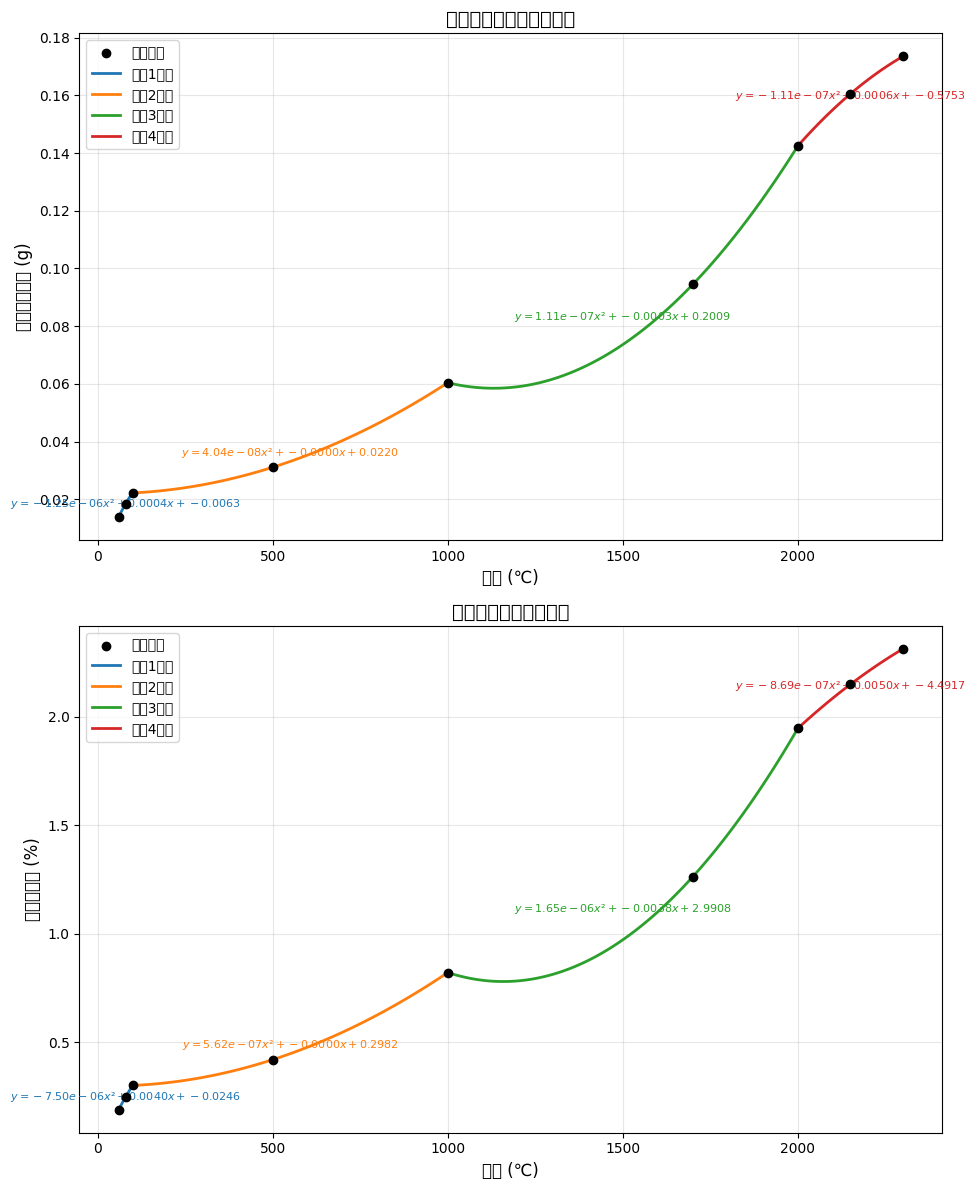

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 原始数据
data = [
    [60, 7.3392, 7.3530, 0.0138, 0.1881],
    [80, 7.4916, 7.5101, 0.0185, 0.2470],
    [100, 7.4056, 7.4278, 0.0222, 0.2999],
    [500, 7.4330, 7.4641, 0.0311, 0.4189],
    [1000, 7.3603, 7.4206, 0.0604, 0.8205],
    [1700, 7.4833, 7.5778, 0.0945, 1.2630],
    [2000, 7.3175, 7.4600, 0.1425, 1.9472],
    [2150, 7.4658, 7.6263, 0.1605, 2.1499],
    [2300, 7.5005, 7.6740, 0.1735, 2.3135]
]

# 数据预处理
sorted_data = sorted(data, key=lambda x: x[0])
temperatures = np.array([x[0] for x in sorted_data])
C = np.array([x[3] for x in sorted_data])  # 氧化质量增量
D = np.array([x[4] for x in sorted_data])  # 氧化质量比

# 定义颜色列表
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

def fit_and_plot(ax, y_data, y_label, title):
    """通用拟合和绘图函数"""
    # 划分四个拟合区间（每组3个连续数据点）
    segments = [
        (0, 1, 2),    # 60,80,100
        (2, 3, 4),    # 100,500,1000
        (4, 5, 6),    # 1000,1700,2000
        (6, 7, 8)     # 2000,2150,2300
    ]
    
    # 绘制原始数据
    ax.scatter(temperatures, y_data, color='black', zorder=5, label='原始数据')
    
    # 对每个区间进行二次拟合
    for idx, (i1, i2, i3) in enumerate(segments):
        # 获取三个数据点
        x_points = temperatures[[i1, i2, i3]]
        y_points = y_data[[i1, i2, i3]]
        
        # 构建系数矩阵
        A = np.vstack([x_points**2, x_points, np.ones(3)]).T
        # 解线性方程组
        try:
            a, b, c = np.linalg.solve(A, y_points)
        except np.linalg.LinAlgError:
            print(f"矩阵奇异，无法求解区间{idx+1}")
            continue
        
        # 生成拟合曲线
        x_fit = np.linspace(x_points.min(), x_points.max(), 100)
        y_fit = a*x_fit**2 + b*x_fit + c
        
        # 绘制拟合曲线
        ax.plot(x_fit, y_fit, 
                color=colors[idx],
                linewidth=2,
                label=f'区间{idx+1}拟合')
        
        # 标注方程
        equation = f"$y = {a:.2e}x² + {b:.4f}x + {c:.4f}$"
        ax.text(np.mean(x_fit), np.mean(y_fit), equation,
                fontsize=8, color=colors[idx],
                ha='center', va='center')

    ax.set_xlabel('温度 (℃)', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()

# 创建画布
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# 绘制氧化质量增量
fit_and_plot(ax1, C, '氧化质量增量 (g)', '氧化质量增量随温度变化')

# 绘制氧化质量比
fit_and_plot(ax2, D, '氧化质量比 (%)', '氧化质量比随温度变化')

plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_19512/863182649.py:99: UserWarn

氧化起始温度检测结果：60.0℃
线性阶段斜率：4.86e-04 g/℃
缓变-加速转折温度：1500.0℃


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

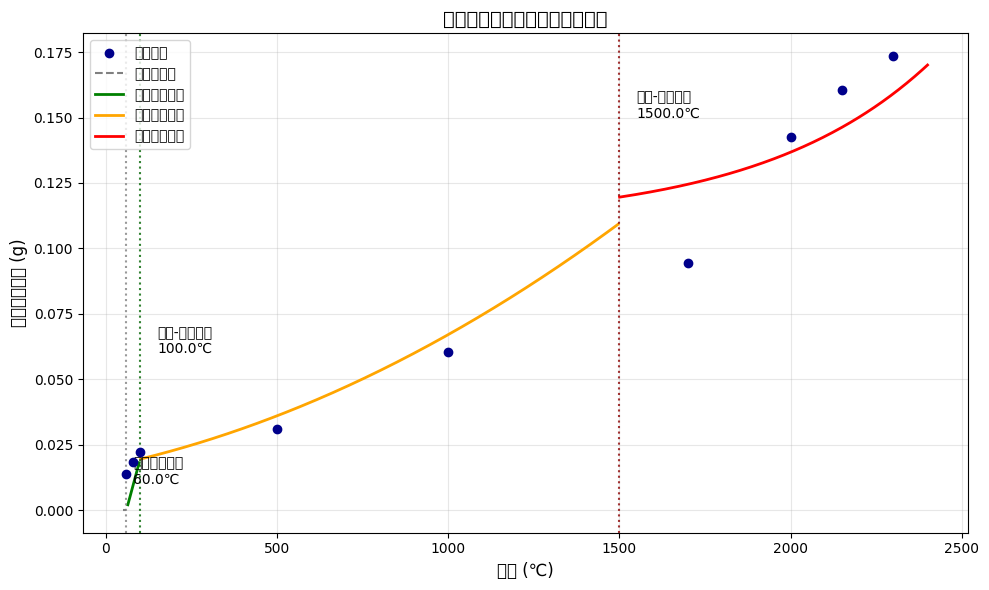

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 数据预处理
data = sorted(data, key=lambda x: x[0])
T = np.array([x[0] for x in data])
C = np.array([x[3] for x in data])  # 氧化质量增量

# 定义复合氧化模型
def oxidation_model(T, T0, k1, k2, k3, T1, T2):
    """
    参数说明：
    T0 - 氧化起始温度
    k1 - 初始线性阶段斜率
    k2 - 中间缓变阶段系数
    k3 - 后期加速阶段系数
    T1 - 线性到缓变的过渡温度
    T2 - 缓变到加速的过渡温度
    """
    y = np.zeros_like(T, dtype=float)
    
    # 氧化前基线（假设无质量变化）
    mask = T < T0
    y[mask] = 0
    
    # 初始线性氧化阶段
    mask = (T >= T0) & (T < T1)
    y[mask] = k1*(T[mask]-T0)
    
    # 缓变氧化阶段（二次过渡）
    mask = (T >= T1) & (T < T2)
    delta_T = T[mask] - T1
    y[mask] = k1*(T1-T0) + k2*delta_T*(1 + delta_T/(T2-T1))
    
    # 加速氧化阶段（指数增长）
    mask = T >= T2
    delta_T = T[mask] - T2
    y[mask] = k1*(T1-T0) + k2*(T2-T1)*(1 + (T2-T1)/(T2-T1)) + k3*np.exp(0.002*delta_T)
    
    return y

# 初始参数估计
p0 = [
    80,   # T0 初始猜测（根据低温数据趋势）
    5e-4, # k1 初始斜率
    2e-5, # k2 缓变系数
    1e-3, # k3 加速系数
    150,  # T1 首次转折温度
    1600  # T2 二次转折温度
]

# 参数边界约束
bounds = (
    [60, 1e-5, 1e-6, 1e-5, 100, 1500],  # 下限
    [120, 1e-3, 1e-3, 1e-2, 500, 2000]   # 上限
)

# 执行拟合
params, cov = curve_fit(oxidation_model, T, C, p0=p0, bounds=bounds, maxfev=5000)
T0_fit, k1_fit, k2_fit, k3_fit, T1_fit, T2_fit = params

# 生成拟合曲线
T_plot = np.linspace(50, 2400, 500)
C_fit = oxidation_model(T_plot, *params)

# 可视化
plt.figure(figsize=(10,6))
plt.scatter(T, C, color='darkblue', label='实验数据', zorder=5)

# 绘制分段特征
mask = T_plot < T0_fit
plt.plot(T_plot[mask], C_fit[mask], 'gray', linestyle='--', label='氧化前基线')

mask = (T_plot >= T0_fit) & (T_plot < T1_fit)
plt.plot(T_plot[mask], C_fit[mask], 'green', linewidth=2, label='线性氧化阶段')

mask = (T_plot >= T1_fit) & (T_plot < T2_fit)
plt.plot(T_plot[mask], C_fit[mask], 'orange', linewidth=2, label='缓变氧化阶段')

mask = T_plot >= T2_fit
plt.plot(T_plot[mask], C_fit[mask], 'red', linewidth=2, label='加速氧化阶段')

# 标注特征参数
plt.axvline(T0_fit, color='gray', linestyle=':', alpha=0.8)
plt.text(T0_fit+20, 0.01, f'氧化起始温度\n{T0_fit:.1f}℃', ha='left')

plt.axvline(T1_fit, color='darkgreen', linestyle=':', alpha=0.8)
plt.text(T1_fit+50, 0.06, f'线性-缓变转折\n{T1_fit:.1f}℃', ha='left')

plt.axvline(T2_fit, color='darkred', linestyle=':', alpha=0.8)
plt.text(T2_fit+50, 0.15, f'缓变-加速转折\n{T2_fit:.1f}℃', ha='left')

plt.xlabel('温度 (℃)', fontsize=12)
plt.ylabel('氧化质量增量 (g)', fontsize=12)
plt.title('材料氧化过程三阶段动力学模型', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 输出关键参数
print(f"氧化起始温度检测结果：{T0_fit:.1f}℃")
print(f"线性阶段斜率：{k1_fit:.2e} g/℃")
print(f"缓变-加速转折温度：{T2_fit:.1f}℃")

plt.show()

In the thermal shock experiment at 500-1300°C:
The initial mass of the specimen is: 7.5219g
The rapid oxidation period occurs before 9 cycles.
The oxidation increment is 0.0047g, and the oxidation percentage is 0.0620%
The equivalent oxidation percentage is 0.0976%
It accounts for 17.1450% of the maximum oxidation mass.
The oxidation rate during the rapid oxidation period is 0.0005g/cycle, equivalent to 0.0000g/s
The maximum oxidation is reached at 73 cycles.
The maximum oxidation increment is 0.0272g, and the maximum oxidation percentage is 0.3613%
The maximum equivalent oxidation percentage is 0.5694%
The oxidation rate during the deep oxidation period is 0.0004g/cycle, equivalent to 0.0000g/s
No shedding period observed after reaching the maximum oxidation.
--------------------------------------------------


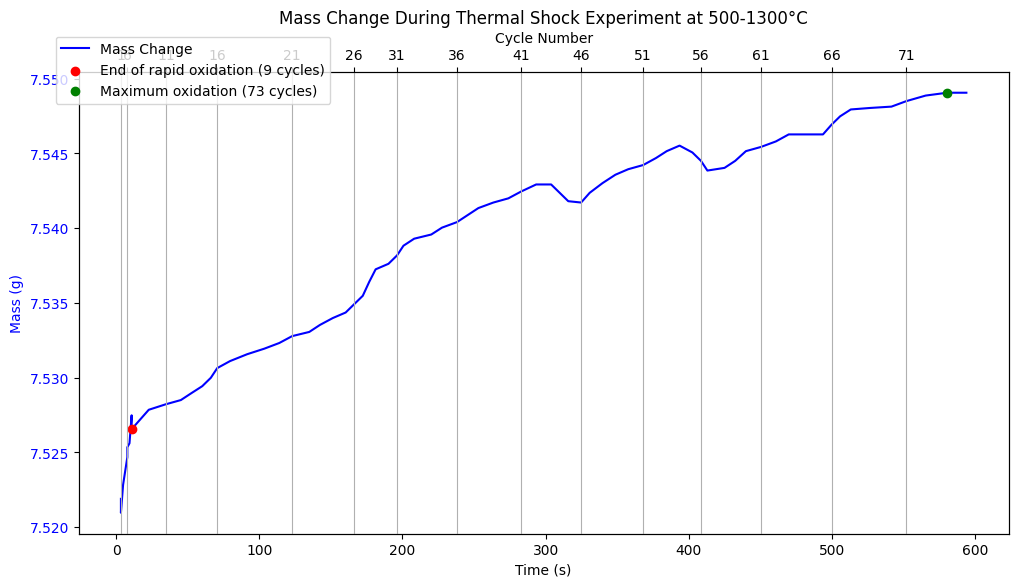

In the thermal shock experiment at 500-1600°C:
The initial mass of the specimen is: 6.7907g
The rapid oxidation period occurs before 7 cycles.
The oxidation increment is 0.0131g, and the oxidation percentage is 0.1936%
The equivalent oxidation percentage is 0.3051%
It accounts for 77.7646% of the maximum oxidation mass.
The oxidation rate during the rapid oxidation period is 0.0019g/cycle, equivalent to 0.0001g/s
The maximum oxidation is reached at 18 cycles.
The maximum oxidation increment is 0.0169g, and the maximum oxidation percentage is 0.2490%
The maximum equivalent oxidation percentage is 0.3924%
The oxidation rate during the deep oxidation period is 0.0003g/cycle, equivalent to 0.0000g/s
Subsequently, it enters the shedding period with a shedding rate of -0.0021g/cycle, equivalent to -0.0001g/s
--------------------------------------------------


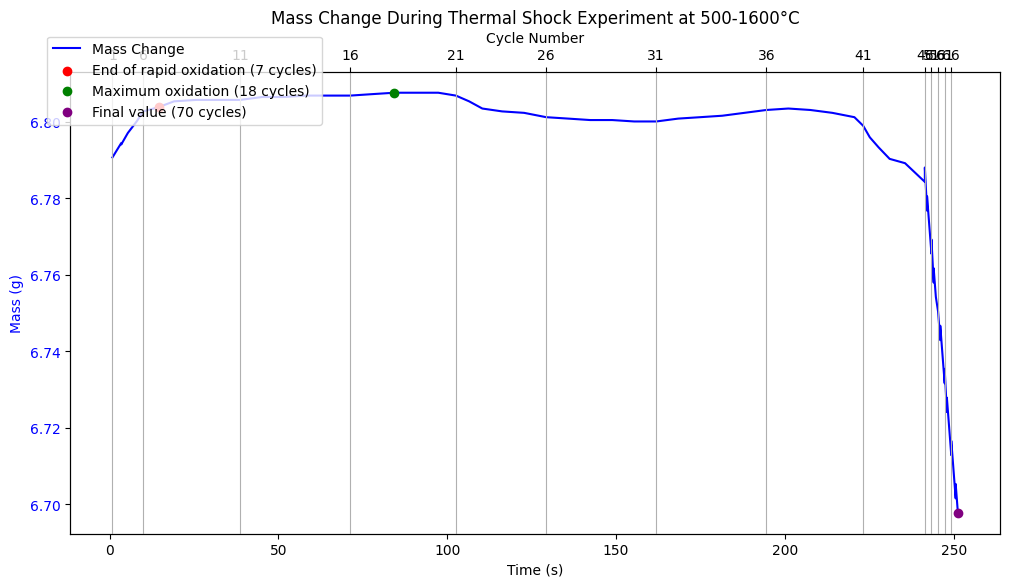

In the thermal shock experiment at 500-1900°C:
The initial mass of the specimen is: 7.5512g
The rapid oxidation period occurs before 5 cycles.
The oxidation increment is 0.0153g, and the oxidation percentage is 0.2024%
The equivalent oxidation percentage is 0.3189%
It accounts for 42.8732% of the maximum oxidation mass.
The oxidation rate during the rapid oxidation period is 0.0031g/cycle, equivalent to 0.0001g/s
The maximum oxidation is reached at 31 cycles.
The maximum oxidation increment is 0.0356g, and the maximum oxidation percentage is 0.4720%
The maximum equivalent oxidation percentage is 0.7437%
The oxidation rate during the deep oxidation period is 0.0008g/cycle, equivalent to 0.0000g/s
Subsequently, it enters the shedding period with a shedding rate of -0.0065g/cycle, equivalent to -0.0003g/s
--------------------------------------------------


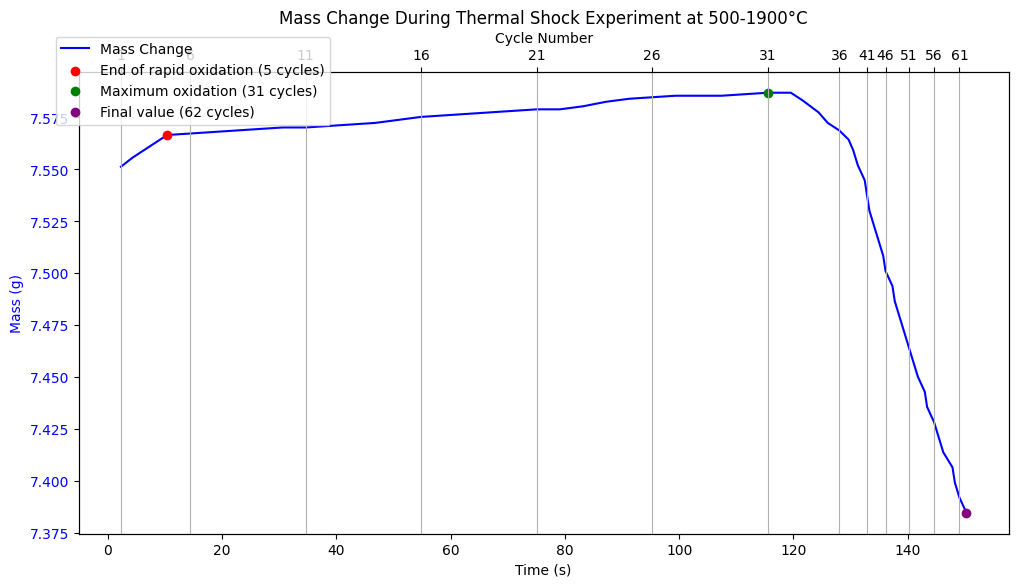

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
df = pd.read_excel("数据.xlsx", header=None)

# 定义三组实验参数
groups = [
    {'temp': '1300', 'time_rows': [19,20], 'weight_row': 20, 'break1': 9},
    {'temp': '1600', 'time_rows': [21,22], 'weight_row': 22, 'break1': 7},
    {'temp': '1900', 'time_rows': [23,24], 'weight_row': 24, 'break1': 5},
]

# 公共系数
coefficient = 1.575757
cycle_time = 25  # 秒/次

for group in groups:
    # 数据准备
    temp_range = f'500-{group["temp"]}'
    
    # 读取时间数据（合并两行）
    time_part1 = df.iloc[group["time_rows"][0], 2:].dropna().values.astype(float)
    time_part2 = df.iloc[group["time_rows"][1], 2:].dropna().values.astype(float)
    time_data = np.concatenate([time_part1, time_part2])
    
    # 读取质量数据
    weight_data = df.iloc[group["weight_row"], 2:].dropna().values.astype(float)
    
    # 对齐数据长度
    min_length = min(len(time_data), len(weight_data))
    time_data = time_data[:min_length]
    weight_data = weight_data[:min_length]
    cycles = np.arange(1, min_length+1)

    # 转折点计算
    break1 = group["break1"]
    max_idx = np.argmax(weight_data)
    has_third = any(weight_data[i] < weight_data[max_idx] for i in range(max_idx+1, len(weight_data)))

    # 计算结果
    initial_mass = weight_data[0]
    
    # 快速氧化期
    fast_delta = weight_data[break1-1] - initial_mass
    fast_percent = (fast_delta / initial_mass) * 100
    max_delta = weight_data[max_idx] - initial_mass
    fast_percent_of_max = (fast_delta / max_delta) * 100 if max_delta != 0 else 0
    fast_rate = fast_delta / break1
    fast_rate_s = fast_rate / cycle_time
    
    # 深度氧化期
    deep_cycles = max_idx - break1 + 1
    deep_delta = weight_data[max_idx] - weight_data[break1-1]
    deep_rate = deep_delta / deep_cycles if deep_cycles > 0 else 0
    deep_rate_s = deep_rate / cycle_time if deep_cycles > 0 else 0
    
    # 脱落期
    if has_third:
        drop_cycles = len(weight_data) - max_idx - 1
        drop_delta = weight_data[-1] - weight_data[max_idx]
        drop_rate = drop_delta / drop_cycles if drop_cycles > 0 else 0
        drop_rate_s = drop_rate / cycle_time if drop_cycles > 0 else 0
    else:
        drop_rate = drop_rate_s = 0

    # 输出结果
    print(f"In the thermal shock experiment at {temp_range}°C:")
    print(f"The initial mass of the specimen is: {initial_mass:.4f}g")
    print(f"The rapid oxidation period occurs before {break1} cycles.")
    print(f"The oxidation increment is {fast_delta:.4f}g, and the oxidation percentage is {fast_percent:.4f}%")
    print(f"The equivalent oxidation percentage is {fast_percent*coefficient:.4f}%")
    print(f"It accounts for {fast_percent_of_max:.4f}% of the maximum oxidation mass.")
    print(f"The oxidation rate during the rapid oxidation period is {fast_rate:.4f}g/cycle, equivalent to {fast_rate_s:.4f}g/s")
    print(f"The maximum oxidation is reached at {max_idx+1} cycles.")
    print(f"The maximum oxidation increment is {max_delta:.4f}g, and the maximum oxidation percentage is {(max_delta/initial_mass)*100:.4f}%")
    print(f"The maximum equivalent oxidation percentage is {(max_delta/initial_mass)*100*coefficient:.4f}%")
    print(f"The oxidation rate during the deep oxidation period is {deep_rate:.4f}g/cycle, equivalent to {deep_rate_s:.4f}g/s")
    
    if has_third:
        print(f"Subsequently, it enters the shedding period with a shedding rate of {drop_rate:.4f}g/cycle, equivalent to {drop_rate_s:.4f}g/s")
    else:
        print("No shedding period observed after reaching the maximum oxidation.")
    print("--------------------------------------------------")

    # 绘制双轴图表
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # 质量曲线
    ax1.plot(time_data, weight_data, 'b-', label='Mass Change')
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Mass (g)", color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # 添加次坐标轴显示循环次数
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(time_data[::5])  # Mark every 5 cycles
    ax2.set_xticklabels(cycles[::5])
    ax2.set_xlabel("Cycle Number")
    
    # 标记关键点
    ax1.scatter(time_data[break1-1], weight_data[break1-1], color='r', zorder=5, 
               label=f'End of rapid oxidation ({break1} cycles)')
    ax1.scatter(time_data[max_idx], weight_data[max_idx], color='g', zorder=5,
               label=f'Maximum oxidation ({max_idx+1} cycles)')
    
    if has_third:
        ax1.scatter(time_data[-1], weight_data[-1], color='purple', zorder=5,
                   label=f'Final value ({len(weight_data)} cycles)')
    
    plt.title(f"Mass Change During Thermal Shock Experiment at {temp_range}°C")
    plt.grid(True)
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
    plt.show()    

In the thermal shock experiment at 500-1300°C:
The initial mass of the specimen is: 7.5219g
The rapid oxidation period occurs before 9 cycles.
The oxidation increment is 0.0047g, and the oxidation percentage is 0.0620%
The equivalent oxidation percentage is 0.0976%
It accounts for 17.1450% of the maximum oxidation mass.
The oxidation rate during the rapid oxidation period is 0.0005g/cycle, equivalent to 0.0000g/s
The maximum oxidation is reached at 73 cycles.
The maximum oxidation increment is 0.0272g, and the maximum oxidation percentage is 0.3613%
The maximum equivalent oxidation percentage is 0.5694%
The oxidation rate during the deep oxidation period is 0.0004g/cycle, equivalent to 0.0000g/s
No shedding period observed after reaching the maximum oxidation.
--------------------------------------------------


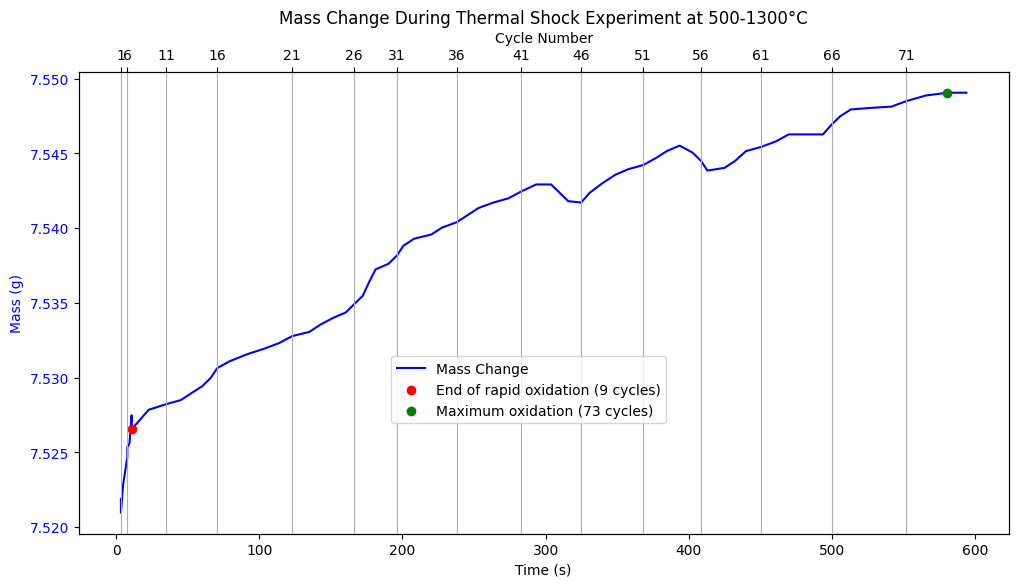

In the thermal shock experiment at 500-1600°C:
The initial mass of the specimen is: 6.7907g
The rapid oxidation period occurs before 7 cycles.
The oxidation increment is 0.0131g, and the oxidation percentage is 0.1936%
The equivalent oxidation percentage is 0.3051%
It accounts for 77.7646% of the maximum oxidation mass.
The oxidation rate during the rapid oxidation period is 0.0019g/cycle, equivalent to 0.0001g/s
The maximum oxidation is reached at 18 cycles.
The maximum oxidation increment is 0.0169g, and the maximum oxidation percentage is 0.2490%
The maximum equivalent oxidation percentage is 0.3924%
The oxidation rate during the deep oxidation period is 0.0003g/cycle, equivalent to 0.0000g/s
Subsequently, it enters the shedding period with a shedding rate of -0.0021g/cycle, equivalent to -0.0001g/s
--------------------------------------------------


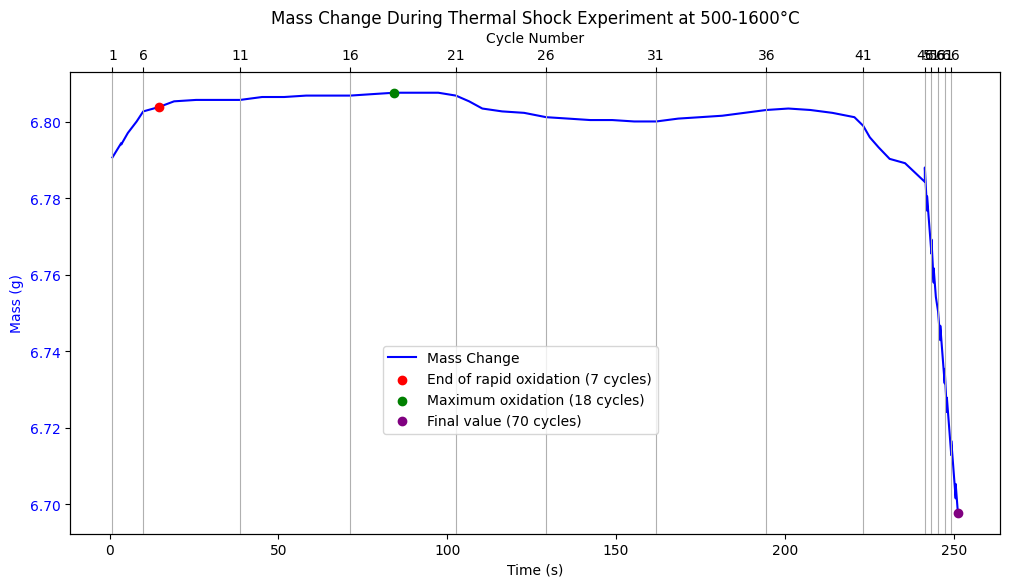

In the thermal shock experiment at 500-1900°C:
The initial mass of the specimen is: 7.5512g
The rapid oxidation period occurs before 5 cycles.
The oxidation increment is 0.0153g, and the oxidation percentage is 0.2024%
The equivalent oxidation percentage is 0.3189%
It accounts for 42.8732% of the maximum oxidation mass.
The oxidation rate during the rapid oxidation period is 0.0031g/cycle, equivalent to 0.0001g/s
The maximum oxidation is reached at 31 cycles.
The maximum oxidation increment is 0.0356g, and the maximum oxidation percentage is 0.4720%
The maximum equivalent oxidation percentage is 0.7437%
The oxidation rate during the deep oxidation period is 0.0008g/cycle, equivalent to 0.0000g/s
Subsequently, it enters the shedding period with a shedding rate of -0.0065g/cycle, equivalent to -0.0003g/s
--------------------------------------------------


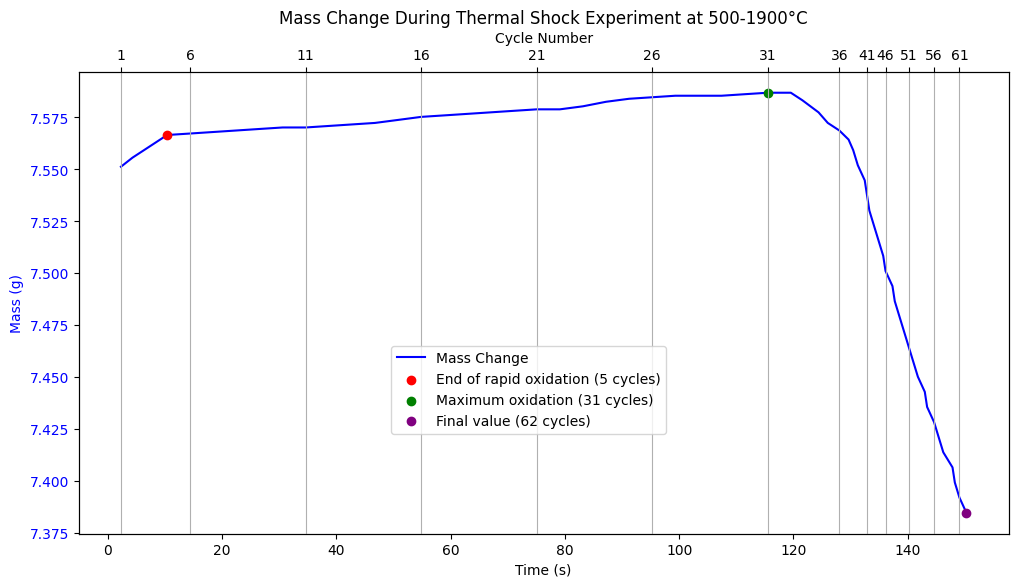

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
df = pd.read_excel("数据.xlsx", header=None)

# 定义三组实验参数
groups = [
    {'temp': '1300', 'time_rows': [19,20], 'weight_row': 20, 'break1': 9},
    {'temp': '1600', 'time_rows': [21,22], 'weight_row': 22, 'break1': 7},
    {'temp': '1900', 'time_rows': [23,24], 'weight_row': 24, 'break1': 5},
]

# 公共系数
coefficient = 1.575757
cycle_time = 25  # 秒/次

for group in groups:
    # 数据准备
    temp_range = f'500-{group["temp"]}'
    
    # 读取时间数据（合并两行）
    time_part1 = df.iloc[group["time_rows"][0], 2:].dropna().values.astype(float)
    time_part2 = df.iloc[group["time_rows"][1], 2:].dropna().values.astype(float)
    time_data = np.concatenate([time_part1, time_part2])
    
    # 读取质量数据
    weight_data = df.iloc[group["weight_row"], 2:].dropna().values.astype(float)
    
    # 对齐数据长度
    min_length = min(len(time_data), len(weight_data))
    time_data = time_data[:min_length]
    weight_data = weight_data[:min_length]
    cycles = np.arange(1, min_length+1)

    # 转折点计算
    break1 = group["break1"]
    max_idx = np.argmax(weight_data)
    has_third = any(weight_data[i] < weight_data[max_idx] for i in range(max_idx+1, len(weight_data)))

    # 计算结果
    initial_mass = weight_data[0]
    
    # 快速氧化期
    fast_delta = weight_data[break1-1] - initial_mass
    fast_percent = (fast_delta / initial_mass) * 100
    max_delta = weight_data[max_idx] - initial_mass
    fast_percent_of_max = (fast_delta / max_delta) * 100 if max_delta != 0 else 0
    fast_rate = fast_delta / break1
    fast_rate_s = fast_rate / cycle_time
    
    # 深度氧化期
    deep_cycles = max_idx - break1 + 1
    deep_delta = weight_data[max_idx] - weight_data[break1-1]
    deep_rate = deep_delta / deep_cycles if deep_cycles > 0 else 0
    deep_rate_s = deep_rate / cycle_time if deep_cycles > 0 else 0
    
    # 脱落期
    if has_third:
        drop_cycles = len(weight_data) - max_idx - 1
        drop_delta = weight_data[-1] - weight_data[max_idx]
        drop_rate = drop_delta / drop_cycles if drop_cycles > 0 else 0
        drop_rate_s = drop_rate / cycle_time if drop_cycles > 0 else 0
    else:
        drop_rate = drop_rate_s = 0

    # 输出结果
    print(f"In the thermal shock experiment at {temp_range}°C:")
    print(f"The initial mass of the specimen is: {initial_mass:.4f}g")
    print(f"The rapid oxidation period occurs before {break1} cycles.")
    print(f"The oxidation increment is {fast_delta:.4f}g, and the oxidation percentage is {fast_percent:.4f}%")
    print(f"The equivalent oxidation percentage is {fast_percent*coefficient:.4f}%")
    print(f"It accounts for {fast_percent_of_max:.4f}% of the maximum oxidation mass.")
    print(f"The oxidation rate during the rapid oxidation period is {fast_rate:.4f}g/cycle, equivalent to {fast_rate_s:.4f}g/s")
    print(f"The maximum oxidation is reached at {max_idx+1} cycles.")
    print(f"The maximum oxidation increment is {max_delta:.4f}g, and the maximum oxidation percentage is {(max_delta/initial_mass)*100:.4f}%")
    print(f"The maximum equivalent oxidation percentage is {(max_delta/initial_mass)*100*coefficient:.4f}%")
    print(f"The oxidation rate during the deep oxidation period is {deep_rate:.4f}g/cycle, equivalent to {deep_rate_s:.4f}g/s")
    
    if has_third:
        print(f"Subsequently, it enters the shedding period with a shedding rate of {drop_rate:.4f}g/cycle, equivalent to {drop_rate_s:.4f}g/s")
    else:
        print("No shedding period observed after reaching the maximum oxidation.")
    print("--------------------------------------------------")

    # 绘制双轴图表
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # 质量曲线
    ax1.plot(time_data, weight_data, 'b-', label='Mass Change')
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Mass (g)", color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # 添加次坐标轴显示循环次数
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(time_data[::5])  # Mark every 5 cycles
    ax2.set_xticklabels(cycles[::5])
    ax2.set_xlabel("Cycle Number")
    
    # 标记关键点
    ax1.scatter(time_data[break1-1], weight_data[break1-1], color='r', zorder=5, 
               label=f'End of rapid oxidation ({break1} cycles)')
    ax1.scatter(time_data[max_idx], weight_data[max_idx], color='g', zorder=5,
               label=f'Maximum oxidation ({max_idx+1} cycles)')
    
    if has_third:
        ax1.scatter(time_data[-1], weight_data[-1], color='purple', zorder=5,
                   label=f'Final value ({len(weight_data)} cycles)')
    
    plt.title(f"Mass Change During Thermal Shock Experiment at {temp_range}°C")
    plt.grid(True)
    
    # 将图例位置调整到横向正中间，纵向稍靠下（上边界:下边界=3:1）
    fig.legend(loc="center", bbox_to_anchor=(0.5, 0.35))
    
    plt.show()    

In [22]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# 读取原始数据
df = pd.read_excel("数据.xlsx", header=None)

# 定义原始温度顺序（假设每两行对应一个温度）
original_temps = [500, 60, 80, 100, 1000, 1700, 2000, 2150, 2300]
data = {}

# 提取每个温度的时间和重量数据
for i, temp in enumerate(original_temps):
    time_row = df.iloc[2*i, 2:].values.astype(float)
    weight_row = df.iloc[2*i + 1, 2:].values.astype(float)
    # 清洗无效数据
    valid_mask = (~np.isnan(time_row)) & (~np.isnan(weight_row)) & (~np.isinf(time_row)) & (~np.isinf(weight_row))
    data[temp] = {
        'time': time_row[valid_mask],
        'weight': weight_row[valid_mask]
    }

# 生成公共时间轴（假设各温度时间序列一致，取最长的时间轴）
common_time = np.unique(np.concatenate([d['time'] for d in data.values()]))
common_time.sort()

# 对各温度数据进行插值以对齐公共时间轴
interpolated_weights = {}
for temp in data:
    time_orig = data[temp]['time']
    weight_orig = data[temp]['weight']
    # 去重并排序
    unique_time, unique_idx = np.unique(time_orig, return_index=True)
    unique_weight = weight_orig[unique_idx]
    # 创建插值函数
    interp_func = interp1d(unique_time, unique_weight, kind='linear', fill_value='extrapolate')
    interpolated_weights[temp] = interp_func(common_time)

# 准备插值温度点（100到2300，每100℃）
target_temps = list(range(100, 2301, 100))
sorted_original_temps = sorted(interpolated_weights.keys())

# 对每个目标温度进行插值
enhanced_data = {}
for temp in target_temps:
    if temp in interpolated_weights:
        # 直接使用现有数据
        enhanced_data[temp] = {
            'time': common_time,
            'weight': interpolated_weights[temp]
        }
    else:
        # 收集相邻温度数据
        known_temps = sorted_original_temps
        known_weights = np.array([interpolated_weights[t] for t in known_temps])
        # 温度插值
        interp_func = interp1d(known_temps, known_weights, axis=0, kind='linear', fill_value='extrapolate')
        enhanced_weight = interp_func(temp)
        enhanced_data[temp] = {
            'time': common_time,
            'weight': enhanced_weight
        }

# 创建DataFrame保存到Sheet2
output_rows = []
for temp in sorted(enhanced_data.keys()):
    # 时间行
    output_rows.append(pd.Series(enhanced_data[temp]['time']))
    # 重量行
    output_rows.append(pd.Series(enhanced_data[temp]['weight']))

# 转换为DataFrame
result_df = pd.DataFrame(output_rows)

# 保存到Excel的Sheet2
with pd.ExcelWriter('数据.xlsx', engine='openpyxl', mode='a') as writer:
    result_df.to_excel(writer, sheet_name='Sheet3', index=False, header=False)

In [21]:
import pandas as pd
import numpy as np

# 恒温氧化数据（温度: 氧化程度）
thermal_data = {
    60: 0.1881, 80: 0.2470, 100: 0.2999, 500: 0.4189,
    1000: 0.8205, 1700: 1.2630, 2000: 1.9472, 2150: 2.1499, 2300: 2.3135
}

# 热震已知数据（高温: 氧化程度）
shock_data = {1300: 0.57, 1600: 0.39, 1900: 0.74}

# 定义分段插值函数计算比例系数k
def calculate_k(T_high):
    if 1300 <= T_high <= 1600:
        return 0.564 + (T_high - 1300) * (-0.0007967)
    elif 1600 < T_high <= 1900:
        return 0.325 + (T_high - 1600) * 0.00035
    else:
        return np.nan  # 超出范围暂不处理

# 生成100-2300℃每隔100℃的热震高温数据
enhanced_shock = {}
for T_high in range(100, 2301, 100):
    if T_high in shock_data:
        enhanced_shock[T_high] = shock_data[T_high]
    else:
        # 插值恒温氧化程度
        temps = sorted(thermal_data.keys())
        O_thermal = np.interp(T_high, temps, [thermal_data[t] for t in temps])
        # 计算比例系数k
        k = calculate_k(T_high) if 1300 <= T_high <= 1900 else 0.4  # 默认值
        enhanced_shock[T_high] = k * O_thermal

# 转换为DataFrame
df_output = pd.DataFrame({
    "高温 (℃)": enhanced_shock.keys(),
    "热震氧化程度 (%)": [round(val, 3) for val in enhanced_shock.values()]
})

# 保存到Excel的Sheet2
with pd.ExcelWriter("数据.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_output.to_excel(writer, sheet_name="Sheet2", index=False)